# 쇼핑몰 거래 분석과 RFM 고객 세분화

거래 전처리부터 배열 특징, 통계, 고객군과 실행 가설까지 같은 분석 결과에서 살펴본다.

## 1. 환경과 분석 실행

UCI Online Retail의 거래 표본을 사용한다. CSV의 수치·범주·날짜를 복원하고 교육용 배열을 처리한다. 분석 실행은 통계와 그림을 새로 만든다.

In [1]:
from pathlib import Path
import sys
from IPython.display import Image, Markdown, display
import numpy as np
import pandas as pd

# 저장소 루트 또는 notebooks 하위에서 실행해도 같은 파일을 찾는다.
start = Path.cwd().resolve()
ROOT = next((p for p in [start, *start.parents] if (p / "src/pipeline.py").is_file()), None)
if ROOT is None:
    raise RuntimeError("저장소 안에서 노트북을 실행하세요")
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
from scripts.run_analysis import run_analysis, FIGURE_METADATA
from scripts.reporting import analytical_notes, korean_summary, SEGMENT_LABELS, write_readme

result = run_analysis(ROOT / "data/online_retail_sample.csv", ROOT / "outputs", ROOT / "figures")
notes = analytical_notes(result)
raw = result["raw_frame"]
df = result["frame"]
rfm = result["rfm"]
write_readme(result, ROOT)
pd.set_option("display.max_columns", 30)
print("입력부터 통계·그림까지 현재 데이터로 생성했습니다.")

입력부터 통계·그림까지 현재 데이터로 생성했습니다.


## 2. 기본 탐색과 기술통계

In [2]:
print(f"원본 표본: {raw.shape[0]:,}행 × {raw.shape[1]}열")
display(raw.drop(columns="product_image").head())
raw.info()
display(raw.select_dtypes(include="number").describe().T)
display(raw.dtypes.astype(str).value_counts().rename("열 수").to_frame())
display(pd.Series(result["overview"]["missing_by_column"], name="결측 수").to_frame())
display(Markdown(notes["statistics"]))
display(Markdown(notes["missing"]))

원본 표본: 25,000행 × 14열


,row_id,source_row_id,invoice_no,stock_code,description,quantity,order_date,unit_price,customer_id,country,amount,image_height,image_width
0,0,2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,8,8
1,1,31,536370,10002,INFLATABLE POLITICAL GLOBE,48,2010-12-01 08:45:00,0.85,12583.0,France,40.80,8,8
2,2,53,536373,37370,RETRO COFFEE MUGS ASSORTED,6,2010-12-01 09:02:00,1.06,17850.0,United Kingdom,6.36,8,8
3,3,112,536381,22771,CLEAR DRAWER KNOB ACRYLIC EDWARDIAN,24,2010-12-01 09:41:00,1.25,15311.0,United Kingdom,30.00,8,8
4,4,123,536381,22083,PAPER CHAIN KIT RETROSPOT,1,2010-12-01 09:41:00,2.95,15311.0,United Kingdom,2.95,8,8


<class 'pandas.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   row_id         25000 non-null  int64         
 1   source_row_id  25000 non-null  int64         
 2   invoice_no     25000 non-null  str           
 3   stock_code     25000 non-null  str           
 4   description    24935 non-null  str           
 5   quantity       25000 non-null  int64         
 6   order_date     25000 non-null  datetime64[us]
 7   unit_price     25000 non-null  float64       
 8   customer_id    18700 non-null  float64       
 9   country        25000 non-null  str           
 10  amount         25000 non-null  float64       
 11  product_image  25000 non-null  object        
 12  image_height   25000 non-null  int64         
 13  image_width    25000 non-null  int64         
dtypes: datetime64[us](1), float64(3), int64(5), object(1), str(4)
memory usage: 2.7+ 

,count,mean,std,min,25%,50%,75%,max
row_id,25000.0,12499.500000,7217.022701,0.0,6249.75,12499.50,18749.25,24999.00
source_row_id,25000.0,271052.645280,156655.821988,2.0,135444.00,270820.50,406505.50,541898.00
quantity,25000.0,9.505600,43.222214,-2376.0,1.00,3.00,10.00,2880.00
unit_price,25000.0,5.111353,120.066142,0.0,1.25,2.08,4.13,13541.33
customer_id,18700.0,15257.567166,1713.557230,12347.0,13899.75,15078.00,16764.00,18287.00
amount,25000.0,17.487655,131.268746,-11586.5,3.38,9.75,17.40,13541.33
image_height,25000.0,8.000000,0.000000,8.0,8.00,8.00,8.00,8.00
image_width,25000.0,8.000000,0.000000,8.0,8.00,8.00,8.00,8.00


,열 수
int64,5
str,4
float64,3
datetime64[us],1
object,1


,결측 수
row_id,0
source_row_id,0
invoice_no,0
stock_code,0
description,65
quantity,0
order_date,0
unit_price,0
customer_id,6300
country,0


- **수량**: 평균 9.51, 중앙값 3.00, 표준편차 43.22, Q1 1.00, Q3 10.00. 평균·중앙값 차이와 큰 변동성을 함께 확인하고 일반적인 거래는 중앙값과 사분위 범위로 설명한다.
- **단가(GBP)**: 평균 5.11, 중앙값 2.08, 표준편차 120.07, Q1 1.25, Q3 4.13. 평균·중앙값 차이와 큰 변동성을 함께 확인하고 일반적인 거래는 중앙값과 사분위 범위로 설명한다.
- **거래금액(GBP)**: 평균 17.49, 중앙값 9.75, 표준편차 131.27, Q1 3.38, Q3 17.40. 평균·중앙값 차이와 큰 변동성을 함께 확인하고 일반적인 거래는 중앙값과 사분위 범위로 설명한다.

반품·취소가 포함된 거래 표본의 기술통계다. 원본과 조정 금액을 구분해서 사용한다.

상품 설명 결측 65건은 같은 상품 코드의 최빈값으로 보완해 0건이 되었다. `description_imputed`에 대치 위치를 남긴다. 고객 ID 결측 6,300건은 식별자를 조작하지 않고 RFM에서 제외한다.

상품명에는 평균이 정의되지 않아 최빈값이 적합하다. 수치형은 그룹 평균 또는 중앙값을 인자로 선택한다. 평균은 극단값에 민감하며 중앙값은 상대적으로 강건하다. 그룹 전체가 결측이면 전체 통계로 보완하거나 결측을 유지한다. 대치는 관측값만으로 계산한 분산을 줄이고 기존 그룹 차이를 실제보다 뚜렷하게 보이게 할 수 있다. 별도 교육용 예제에서 관측 수·그룹 평균·표본 분산을 비교하며 실제 거래에 인위적 결측을 넣지 않는다.

## 3. 파이프라인 책임과 인자

`DataAnalyzer`는 DataFrame 상태를 관리하고 각 단계의 책임을 분리한다.
`load_data()`는 입력 형식·크기·날짜·배열을 확인하고, `handle_missing_values()`는 결측 정책을 적용한다.
`engineer_features()`는 수치·텍스트·배열 특징을 만들고, `detect_outliers()`는 경계 밖 행을 찾는다.
`treat_outliers()`는 처리 정책을 적용하며, `calculate_rfm()`은 고객 단위 집계와 점수를 만든다.
`segment_summary()`는 고객군의 규모와 금액 기여도를 요약한다.
이 분리는 결측 정책만 교체하거나 집계만 다시 실행하고, 단계별 입력·출력과 상태 변화를 따로 검증할 수 있게 한다.

`outlier_threshold`는 분포에 맞는 탐지 강도를, `strategy`·`group_col`·`columns`는 데이터에 맞는 대치를,
`reference_date`는 같은 시점의 재현 가능한 최근성을 지정한다. `score_bins`와 `recent_days`는 상대 점수와
절대 구매주기 기준을 비교한다. 다른 파일·정책을 적용할 때 함수 내부 상수를 고칠 필요가 없다.
`handle_missing()`은 기존 호출과의 호환을 위한 이름이며 공개 API인 `handle_missing_values()`와 같은 구현을 사용한다.

In [3]:
display(Markdown(notes["design"]))

`DataAnalyzer`는 DataFrame 상태를 관리하고 각 단계의 책임을 분리한다.
`load_data()`는 입력 형식·크기·날짜·배열을 확인하고, `handle_missing_values()`는 결측 정책을 적용한다.
`engineer_features()`는 수치·텍스트·배열 특징을 만들고, `detect_outliers()`는 경계 밖 행을 찾는다.
`treat_outliers()`는 처리 정책을 적용하며, `calculate_rfm()`은 고객 단위 집계와 점수를 만든다.
`segment_summary()`는 고객군의 규모와 금액 기여도를 요약한다.
이 분리는 결측 정책만 교체하거나 집계만 다시 실행하고, 단계별 입력·출력과 상태 변화를 따로 검증할 수 있게 한다.

`outlier_threshold`는 분포에 맞는 탐지 강도를, `strategy`·`group_col`·`columns`는 데이터에 맞는 대치를,
`reference_date`는 같은 시점의 재현 가능한 최근성을 지정한다. `score_bins`와 `recent_days`는 상대 점수와
절대 구매주기 기준을 비교한다. 다른 파일·정책을 적용할 때 함수 내부 상수를 고칠 필요가 없다.
`handle_missing()`은 기존 호출과의 호환을 위한 이름이며 공개 API인 `handle_missing_values()`와 같은 구현을 사용한다.

## 4. 결측 처리와 그룹 통계 비교

아래 수치형 대치 예제는 실제 거래와 분리한 교육용 데이터다.

In [4]:
display(pd.DataFrame(result["missing_report"]).rename(columns={"before": "처리 전", "after": "처리 후"}))
display(result["imputation_values"])
display(result["imputation_statistics"].round(3))
print("그룹 전체가 결측일 때는 전체 통계 대치 또는 결측 유지 정책을 선택합니다.")

,처리 전,처리 후
row_id,0.0,0
source_row_id,0.0,0
invoice_no,0.0,0
stock_code,0.0,0
description,65.0,0
quantity,0.0,0
order_date,0.0,0
unit_price,0.0,0
customer_id,6300.0,6300
country,0.0,0


,상품 그룹,관측값만,전역 평균,그룹 평균,그룹 중앙값
0,A,1.0,1.0,1.0,1.0
1,A,3.0,3.0,3.0,3.0
2,A,101.0,101.0,101.0,101.0
3,A,NaN,23.5,35.0,3.0
4,B,10.0,10.0,10.0,10.0
5,B,12.0,12.0,12.0,12.0
6,B,14.0,14.0,14.0,14.0
7,B,NaN,23.5,12.0,12.0


,대치 방법,상품 그룹,관측 수,평균,표본 분산
0,관측값만,A,3,35.000,3268.000
1,관측값만,B,3,12.000,4.000
2,전역 평균,A,4,32.125,2211.729
3,전역 평균,B,4,14.875,35.729
4,그룹 평균,A,4,35.000,2178.667
5,그룹 평균,B,4,12.000,2.667
6,그룹 중앙값,A,4,27.000,2434.667
7,그룹 중앙값,B,4,12.000,2.667


그룹 전체가 결측일 때는 전체 통계 대치 또는 결측 유지 정책을 선택합니다.


## 5. 수치·텍스트·배열 특징 공학

,amount,word_count,image_mean,image_std,description_imputed
0,22.00,5,127.0,73.891815,False
1,40.80,3,127.5,72.368843,False
2,6.36,4,129.0,73.864738,False
3,30.00,5,128.5,74.318573,False
4,2.95,4,126.0,72.090218,False


금액은 `quantity.to_numpy() * unit_price.to_numpy()`로 계산한다.
배열 특징은 `np.stack()`으로 동종 자료형의 2차원 행렬을 만든 뒤 `mean(axis=1)`과 `std(axis=1)`로
이미지별 값을 한 번에 구한다. 단어 수는 Pandas 문자열 연산으로 만든다.
CSV 문자열을 배열로 복원하는 입출력 단계에는 행별 처리가 남아 있지만, 평균·표준편차 계산에 Python 행별 for문은 사용하지 않는다.

동종 자료형의 연속 메모리는 포인터 추적을 줄이고 CPU 캐시의 지역성을 높인다.
NumPy의 컴파일된 내부 루프는 Python 원소별 호출과 동적 타입 검사 비용을 줄이며,
지원되는 연산·자료형·CPU에서는 SIMD로 여러 값을 함께 처리할 수 있다.
모든 연산이 SIMD를 사용하거나 작은 배열에서도 항상 빠른 것은 아니다. 전체 행렬을 쌓는 메모리 비용도 고려해야 한다.
현재 0~255 배열은 float32로 충분하며 float64보다 핵심 행렬 메모리가 절반이다.

`product_image`는 `stock_code`를 해시해 만든 8×8 교육용 배열이다.
실제 상품 사진이나 UCI가 제공한 이미지가 아니며 색상·형태·품질을 뜻하지 않는다.
숫자·범주·날짜는 원본 거래에서 확보하고 배열은 파싱·벡터 통계의 동작을 살펴보는 데 사용한다.
실제 상품 이미지 분석으로 확장하려면 공개 라이선스 이미지와 정확한 상품 대응 관계가 필요하다.
관련 없는 사진을 임의로 상품에 연결해서는 안 된다. 빈 배열·길이가 다른 배열·비유한 값은 오류로 드러낸다.

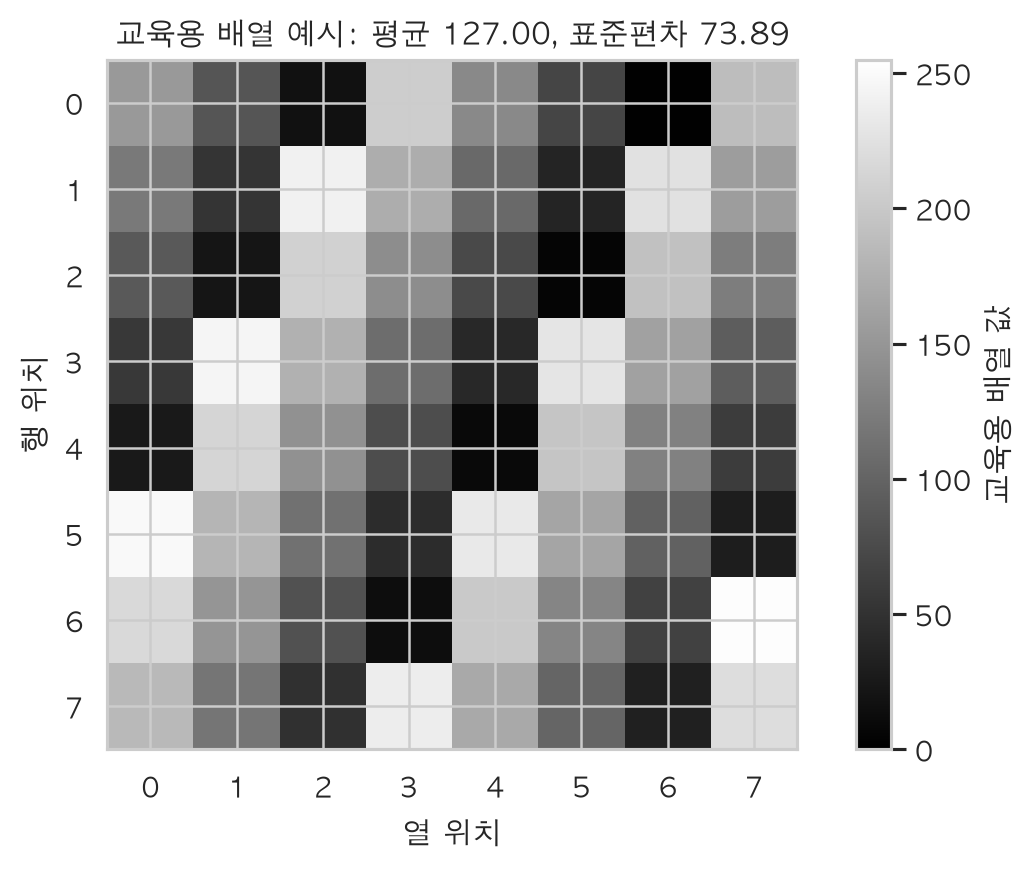

In [5]:
display(df[["amount", "word_count", "image_mean", "image_std", "description_imputed"]].head())
display(Markdown(notes["vector"]))
display(Markdown(notes["image"]))
display(Image(filename=str(ROOT / "figures/08_educational_array.png")))

## 6. IQR 이상치와 분포 변화

,처리 결과
column,amount
method,clip
output_column,amount_clean
before_count,1925
after_count,0
bounds,"{'q1': 3.75, 'q3': 17.700000000000003, 'iqr': ..."


IQR = Q3 − Q1이며 경계는 Q1 − 1.5×IQR, Q3 + 1.5×IQR이다. 양수 거래의 Q1=3.750, Q3=17.700, IQR=13.950, 상한=38.625 GBP다. 경계 밖 1,925건(7.9%)을 클리핑했고 같은 경계 밖 값은 처리 후 0건이다.

IQR은 정규분포를 가정하지 않고 중앙 50%를 이용해 극단값 영향에 비교적 강건하다. 그러나 비대칭의 긴 꼬리나 여러 봉우리가 있는 분포에서는 정상 고액 주문도 과다 표시할 수 있고 전역 경계는 상품·국가별 차이를 무시한다. 이상치는 곧 오류라는 뜻이 아니다. 음수 반품은 보존하고 원본 amount와 조정 amount_clean을 분리한다. 유효 RFM 구매의 원본 합계는 £380,154.47, 조정 합계는 £256,920.02로 32.4% 감소한다. 조정 금액의 매출 비중을 회계 매출이나 실현 이익으로 해석하지 않는다.

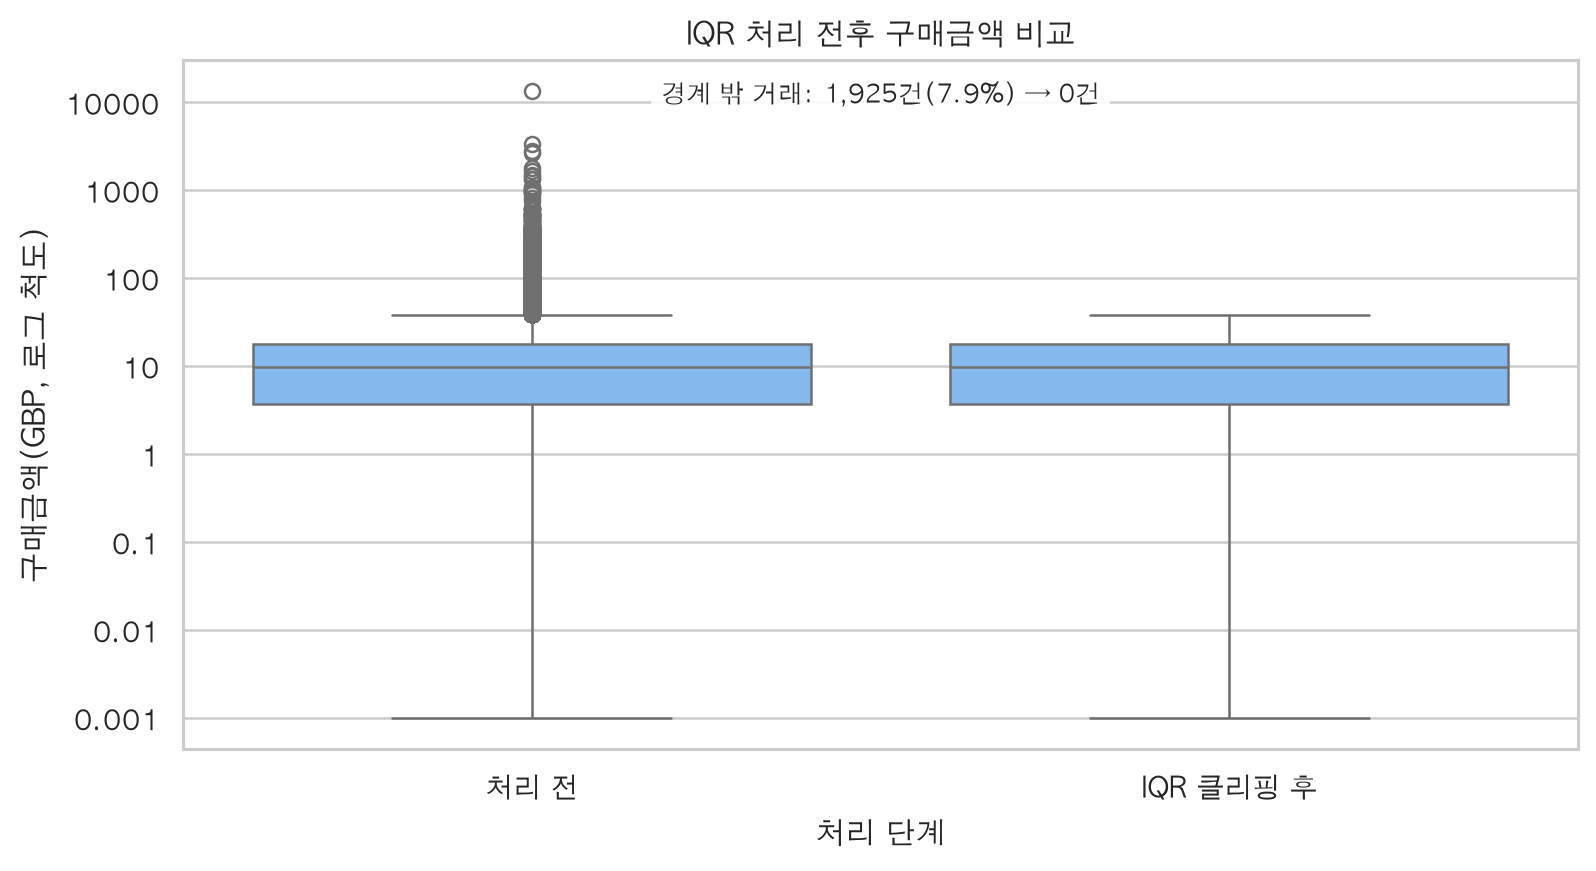

In [6]:
display(pd.Series(result["outlier_report"]).to_frame("처리 결과"))
display(Markdown(notes["iqr"]))
display(Image(filename=str(ROOT / "figures/02_outlier_boxplot.png")))

## 7. RFM 정의와 고객군

기준일은 2011-12-10이다. 기준일과 마지막 구매일의 현지 날짜 차이가 최근성이다. 빈도는 고유 주문번호 수이고 금액은 유효 양수 구매의 조정 금액 합계다.

각 지표의 평균 순위 백분위를 네 점수 구간으로 나누며 최근성은 방향을 반대로 적용한다. 동일 값은 동일 점수를 받고 고객 ID나 정렬 순서에 영향을 받지 않는다. 고객 한 명 또는 상수 지표는 중간 점수로 처리한다. 동점 때문에 각 구간이 정확히 25%가 되거나 모든 점수가 존재하지 않을 수 있다.

기본 네 구간에서 R≥3을 최근 구매로 보고, F≥3·M≥3이면 핵심 우수 고객이다. 최근 구매이면서 F≤2이면 최근 저빈도 고객, R≤2이면 장기 미구매 고객, 나머지는 반복 구매 고객이다. New·Churned는 내부 호환 식별자이며 신규 가입·생애 첫 구매·확정 이탈을 의미하지 않는다. 거래 표본에서 관측한 행동이므로 고객의 전체 이력과 다를 수 있다.

,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_score,Segment
customer_id,,,,,,,,
14911,2,128,5786.890,4,4,4,12,VIP
14646,2,35,3797.240,4,4,4,12,VIP
14096,5,13,2390.960,4,4,4,12,VIP
14298,9,29,2069.470,4,4,4,12,VIP
17841,2,108,1767.990,4,4,4,12,VIP
13089,5,44,1545.370,4,4,4,12,VIP
12748,2,102,1464.495,4,4,4,12,VIP
15311,1,60,1441.020,4,4,4,12,VIP
17511,3,20,1200.670,4,4,4,12,VIP


,고객군,고객 수,고객 비중,평균 최근성,빈도 중앙값,평균 조정 구매금액,조정 금액 비중
0,핵심 우수 고객,947,29.1%,22.4일,4회,£175.75,64.8%
1,장기 미구매 고객,"1,630",50.1%,180.1일,1회,£45.54,28.9%
2,최근 저빈도 고객,461,14.2%,32.6일,1회,£23.63,4.2%
3,반복 구매 고객,213,6.6%,28.9일,2회,£25.12,2.1%


Recency                                      Frequency         \
            count     mean median     std    Q1     Q3     count   mean   
Segment                                                                   
장기 미구매 고객    1630  180.125  162.5  92.439  93.0  254.0      1630  1.703   
반복 구매 고객      213   28.859   27.0  17.035  15.0   41.0       213  2.446   
최근 저빈도 고객     461   32.557   32.0  17.564  19.0   47.0       461  1.000   
핵심 우수 고객      947   22.365   19.0  16.586   8.5   33.0       947  5.787   

                                  Monetary                                   \
          median    std   Q1   Q3    count     mean  median      std     Q1   
Segment                                                                       
장기 미구매 고객    1.0  1.254  1.0  2.0     1630   45.545   32.40   47.969  15.60   
반복 구매 고객     2.0  0.748  2.0  3.0      213   25.123   26.13    8.825  19.50   
최근 저빈도 고객    1.0  0.000  1.0  1.0      461   23.633   17.40   22.296  10.20   
핵심 우수 고객     4.0  7.833  3.0  7.0      947  175.751  112.68  290.629  71.84   

                    
                Q3  
Segment             
장기 미구매 고객   57.154  
반복 구매 고객    32.190  
최근 저빈도 고객   32.340  
핵심 우수 고객   192.405

,지표,점수,고객 수,최솟값,최댓값
0,Recency,1,815,163.00,374.000
1,Recency,2,815,64.00,162.000
2,Recency,3,822,24.00,62.000
3,Recency,4,799,1.00,23.000
4,Frequency,1,1480,1.00,1.000
5,Frequency,3,1070,2.00,3.000
6,Frequency,4,701,4.00,128.000
7,Monetary,1,813,0.39,18.400
8,Monetary,2,815,18.45,38.625
9,Monetary,3,810,38.70,87.840


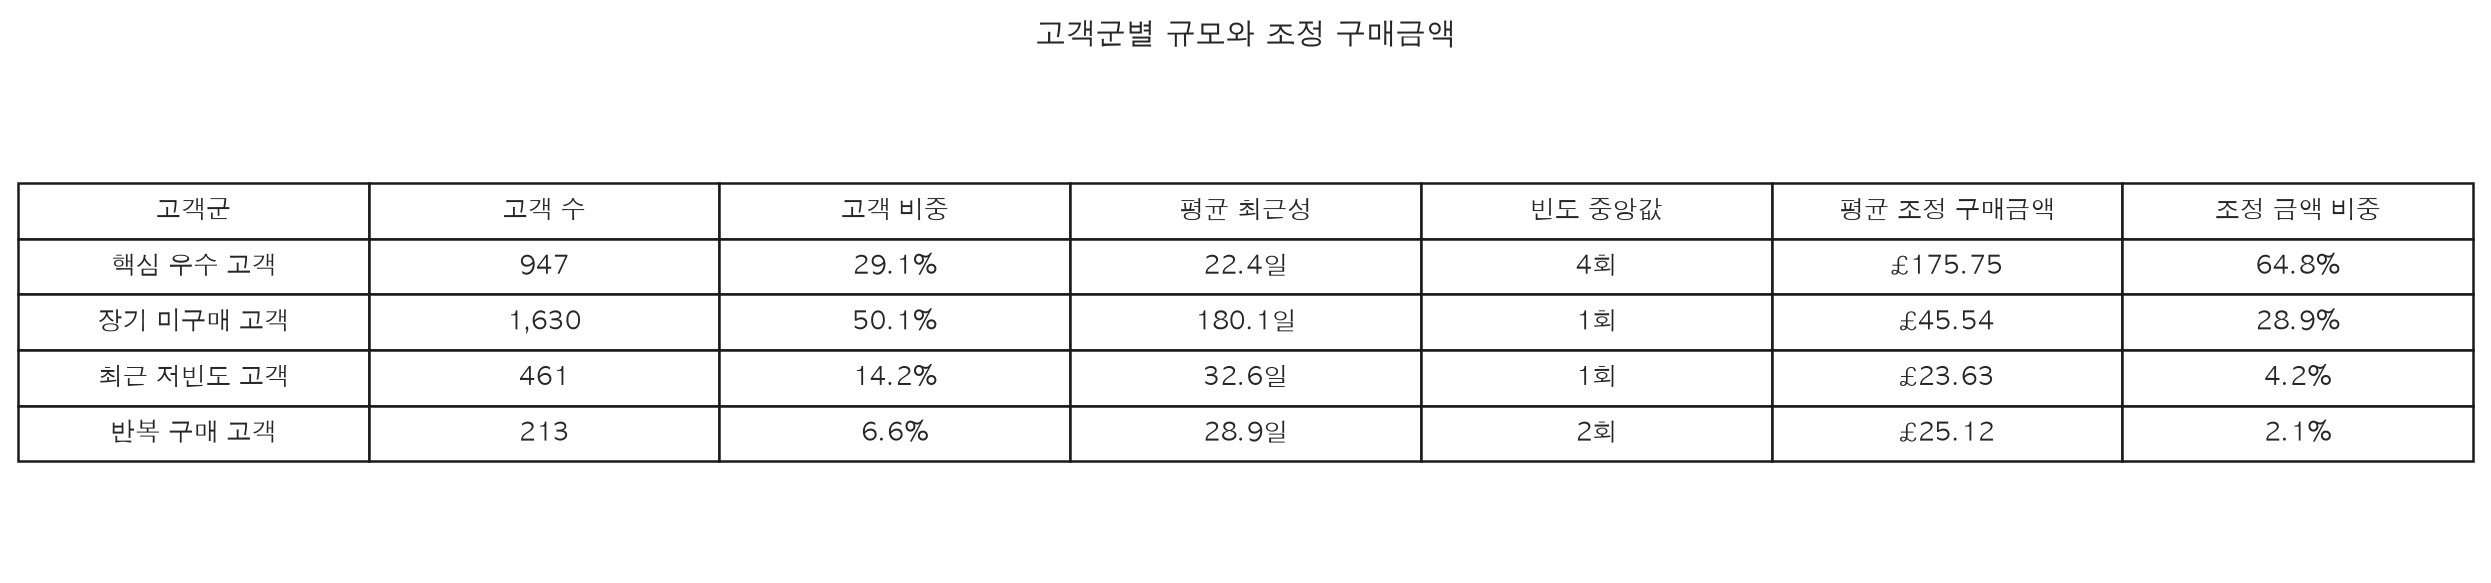

In [7]:
display(Markdown(notes["rfm"]))
display(rfm.head(10))
display(korean_summary(result["segment_summary"]))
display(result["group_statistics"].rename(index=SEGMENT_LABELS).round(3))
display(result["score_ranges"])
display(Image(filename=str(ROOT / "figures/07_segment_summary_table.png")))

## 8. 상관분석과 여섯 종류의 시각화

,Recency,Frequency,Monetary,RFM_score
Recency,1.000000,-0.248072,-0.204311,-0.679924
Frequency,-0.248072,1.000000,0.793888,0.465045
Monetary,-0.204311,0.793888,1.000000,0.414451
RFM_score,-0.679924,0.465045,0.414451,1.000000


- **구매 빈도–조정 구매금액**: Pearson 상관계수 0.794. 더 자주 주문한 고객이 큰 누적 금액을 보이는 경향으로, 반복 구매 고객의 경제적 기여를 함께 살펴볼 근거다. 누적 합계와 빈도의 구조적 연결도 있어 인과 효과는 아니다.
- **최근성–구매 빈도**: Pearson 상관계수 -0.248. 마지막 구매 후 시간이 긴 고객은 주문 빈도가 낮은 경향이지만 관계가 강하지 않으므로 최근성만으로 구매 가치를 판단하지 않는다. 반복 구매 유지와 장기 미구매 회수를 구분해 실험할 시사점이 있다.

최근성과 종합점수의 상관은 -0.680이며 최근성 점수가 산식에 포함된 영향을 받는다.

,파일,종류,제목,가로축,세로축
0,01_amount_histogram.png,히스토그램,양수 구매금액 분포(99백분위 이하),구매금액(GBP),거래 수
1,02_outlier_boxplot.png,박스플롯,IQR 처리 전후 구매금액 비교,처리 단계,"구매금액(GBP, 로그 척도)"
2,03_segment_bar.png,막대그래프,RFM 고객군별 고객 수,고객군,고객 수
3,04_rfm_heatmap.png,히트맵,RFM 지표의 상관관계,RFM 지표,RFM 지표
4,05_rfm_scatter.png,산점도,고객군별 구매 빈도와 조정 구매금액,"구매 빈도(주문 수, 로그 척도)","조정 구매금액(GBP, 로그 척도)"
5,06_monthly_sales_line.png,라인차트,월별 조정 구매금액 추이,거래 월,조정 구매금액 합계(GBP)


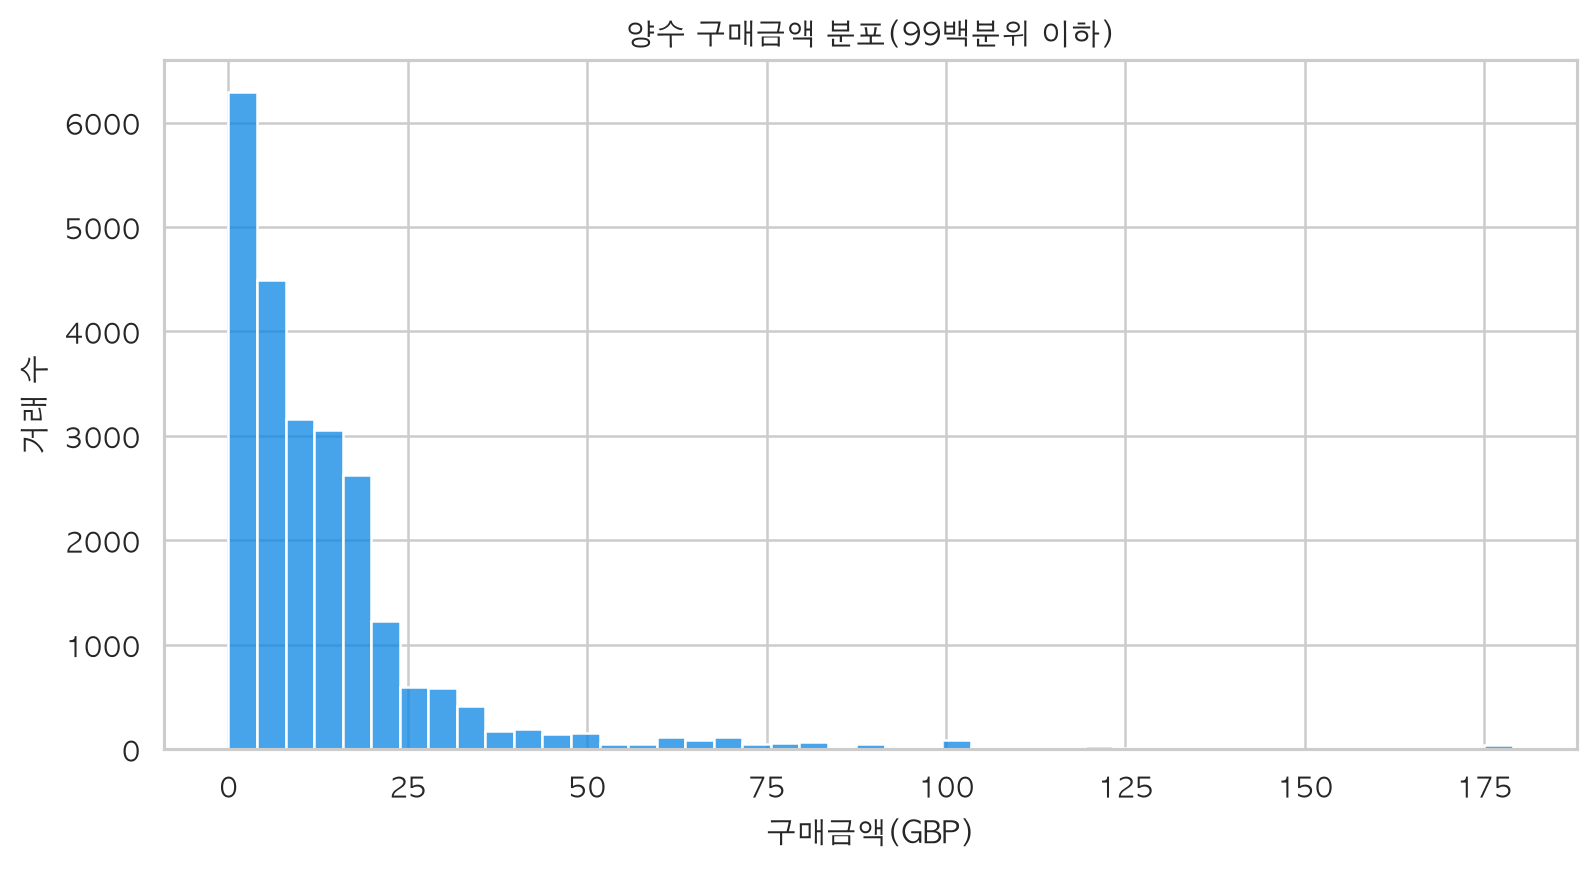

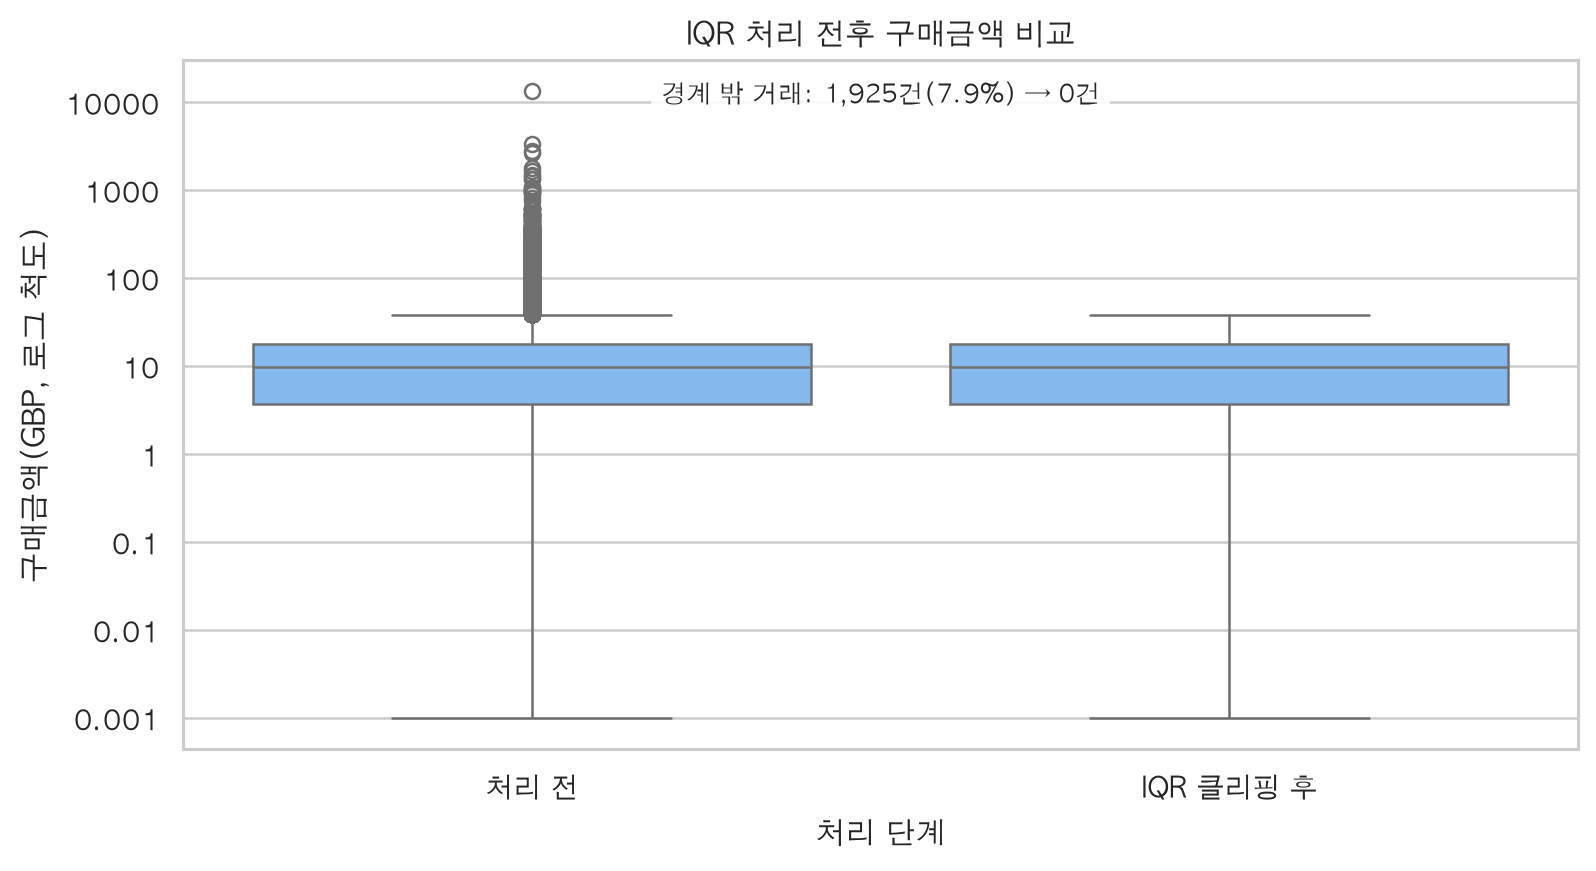

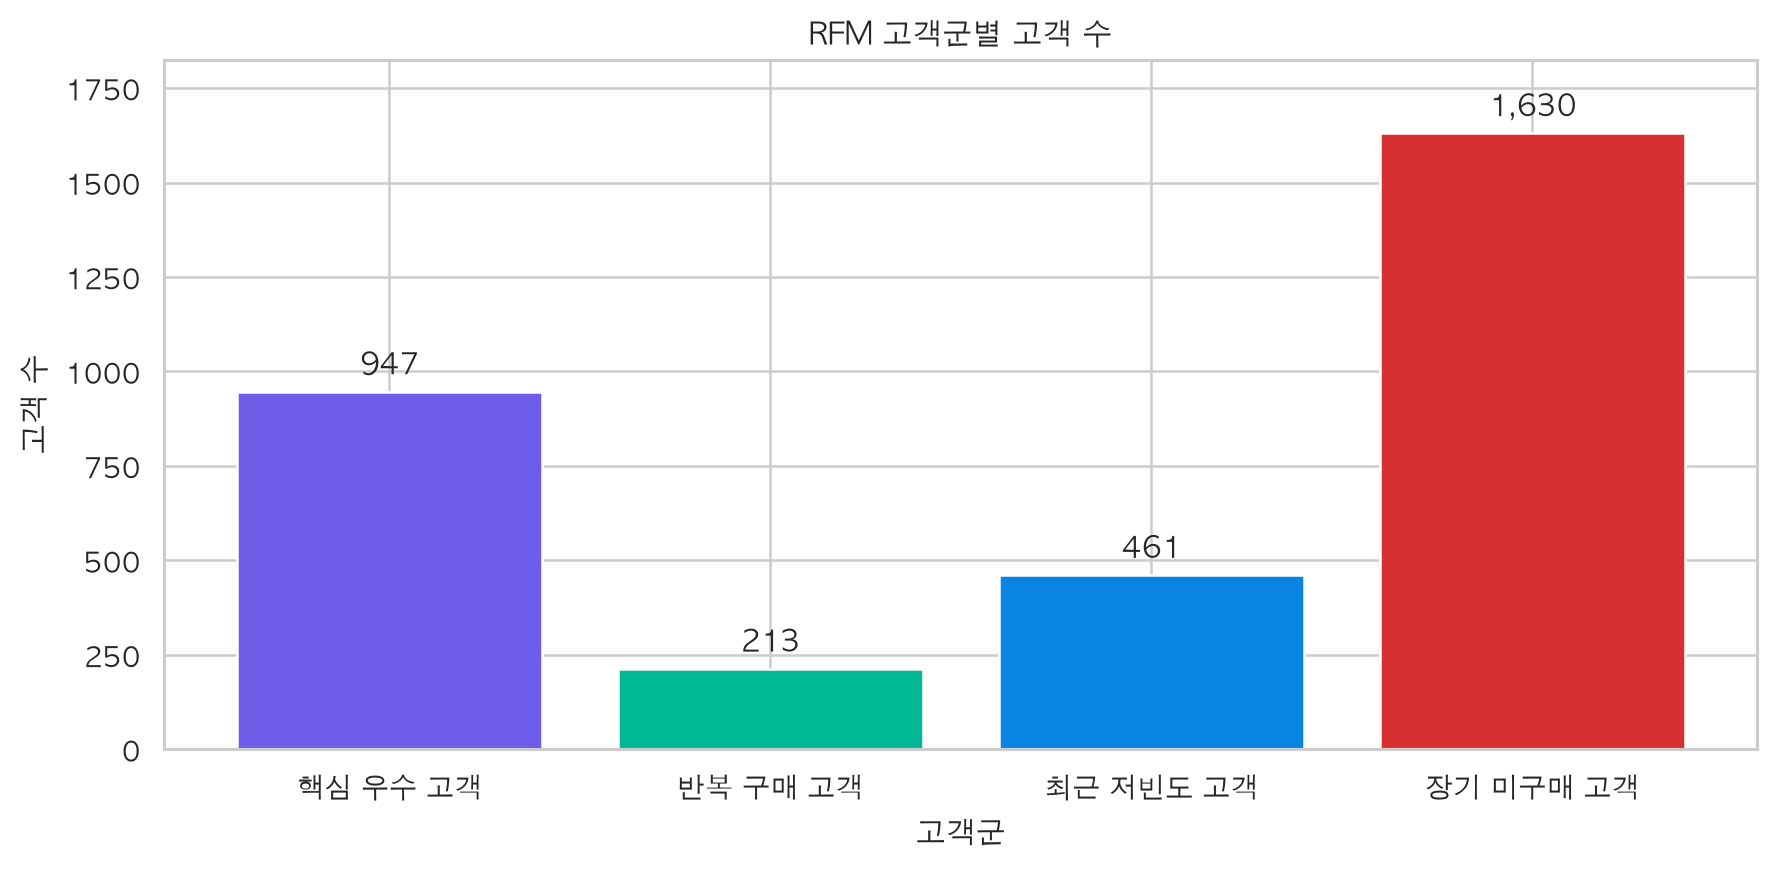

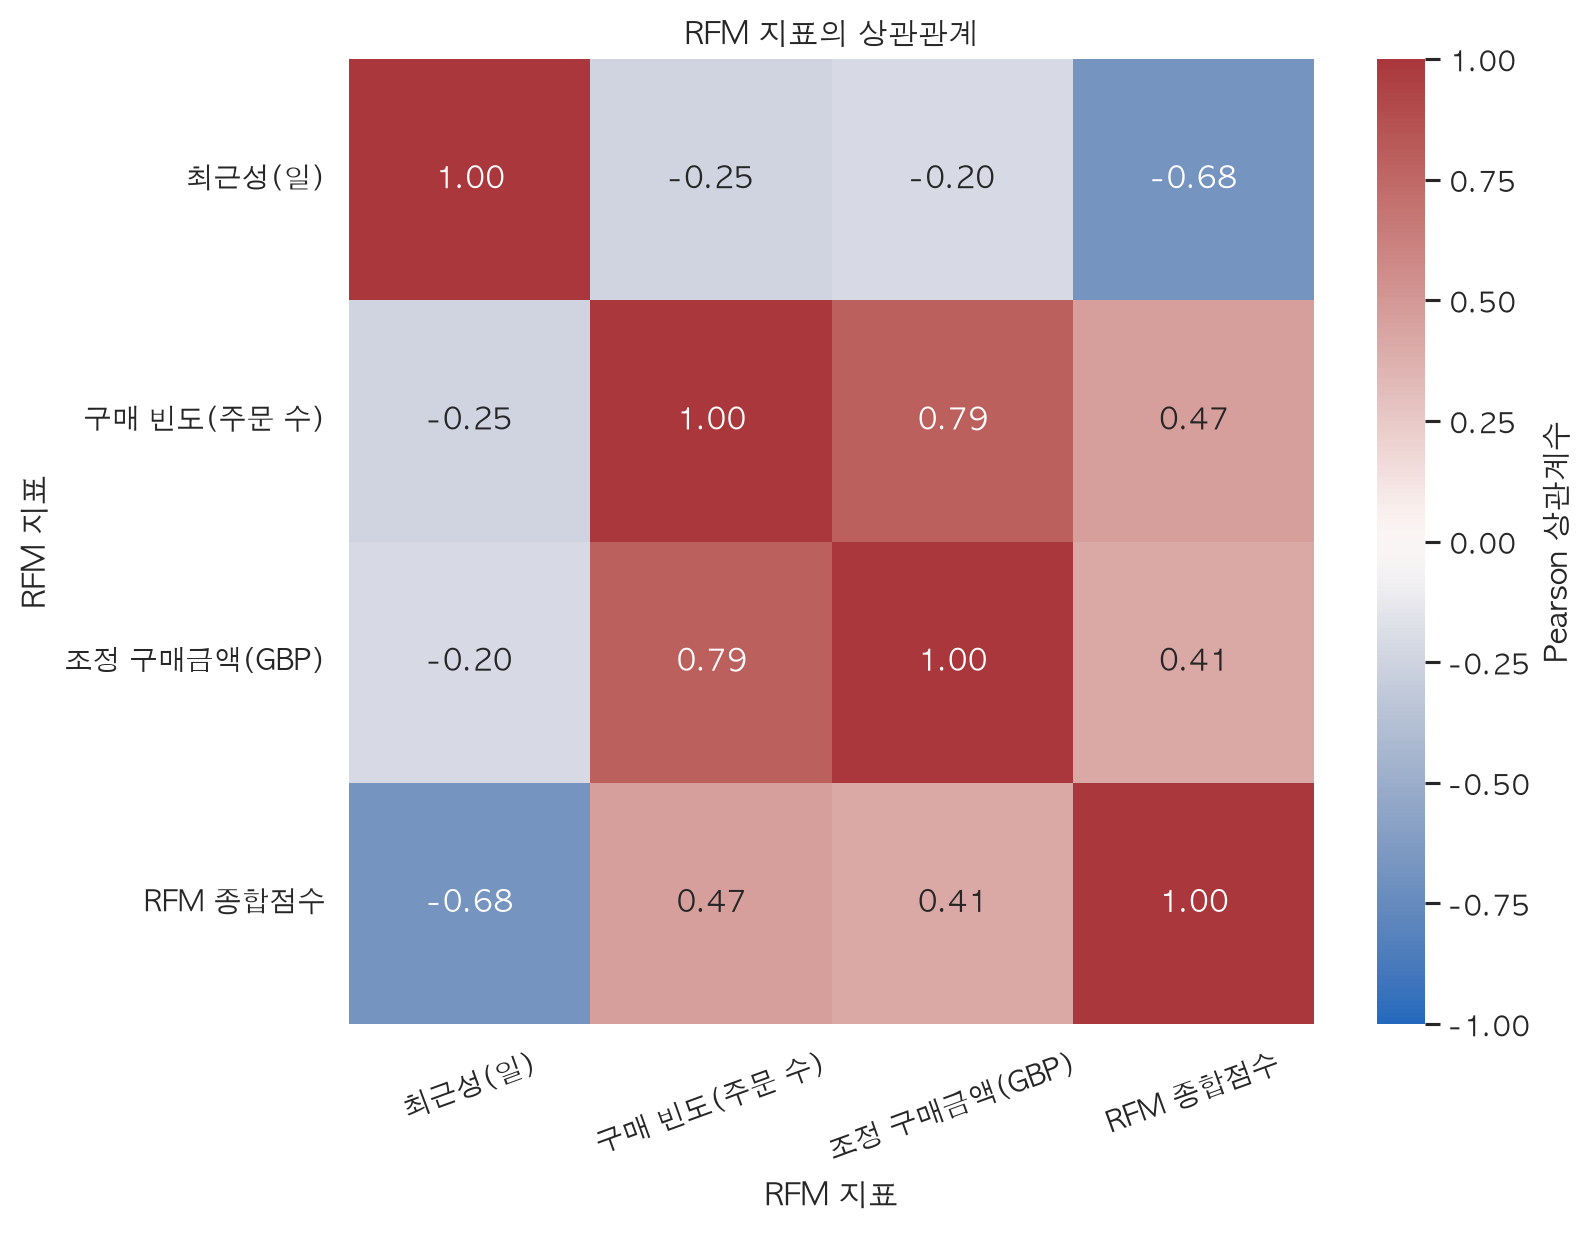

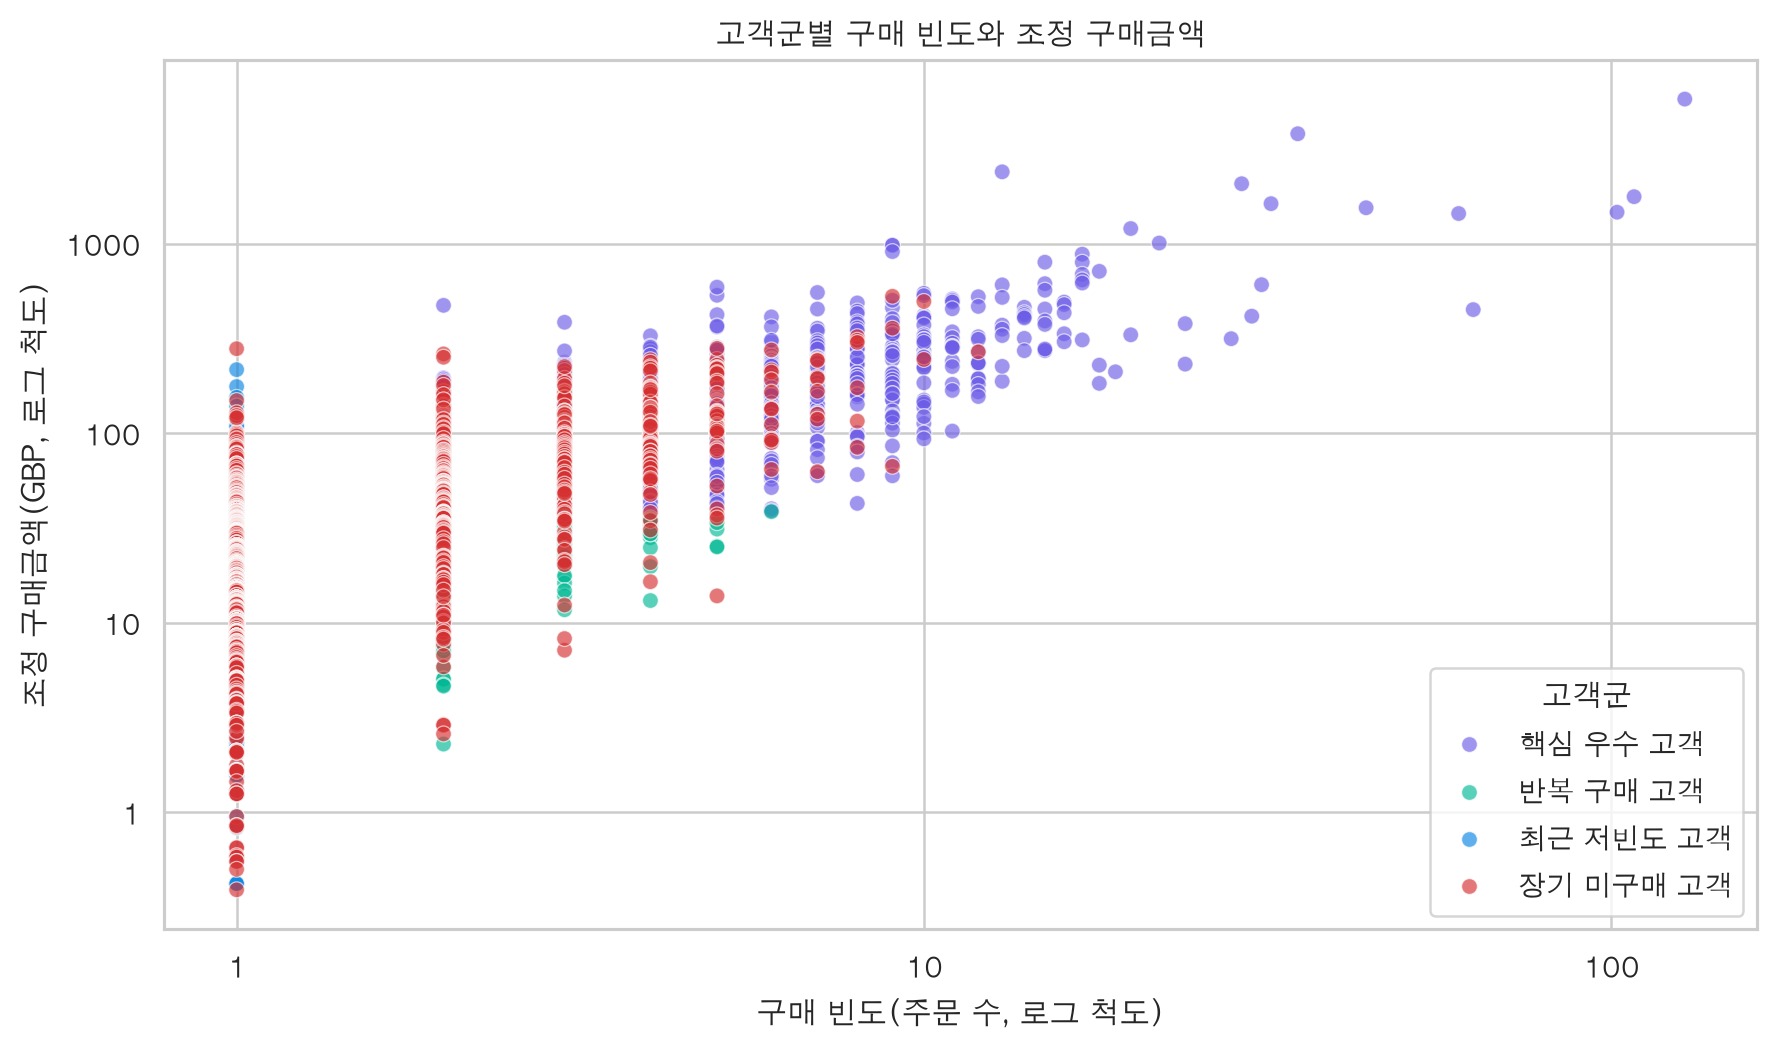

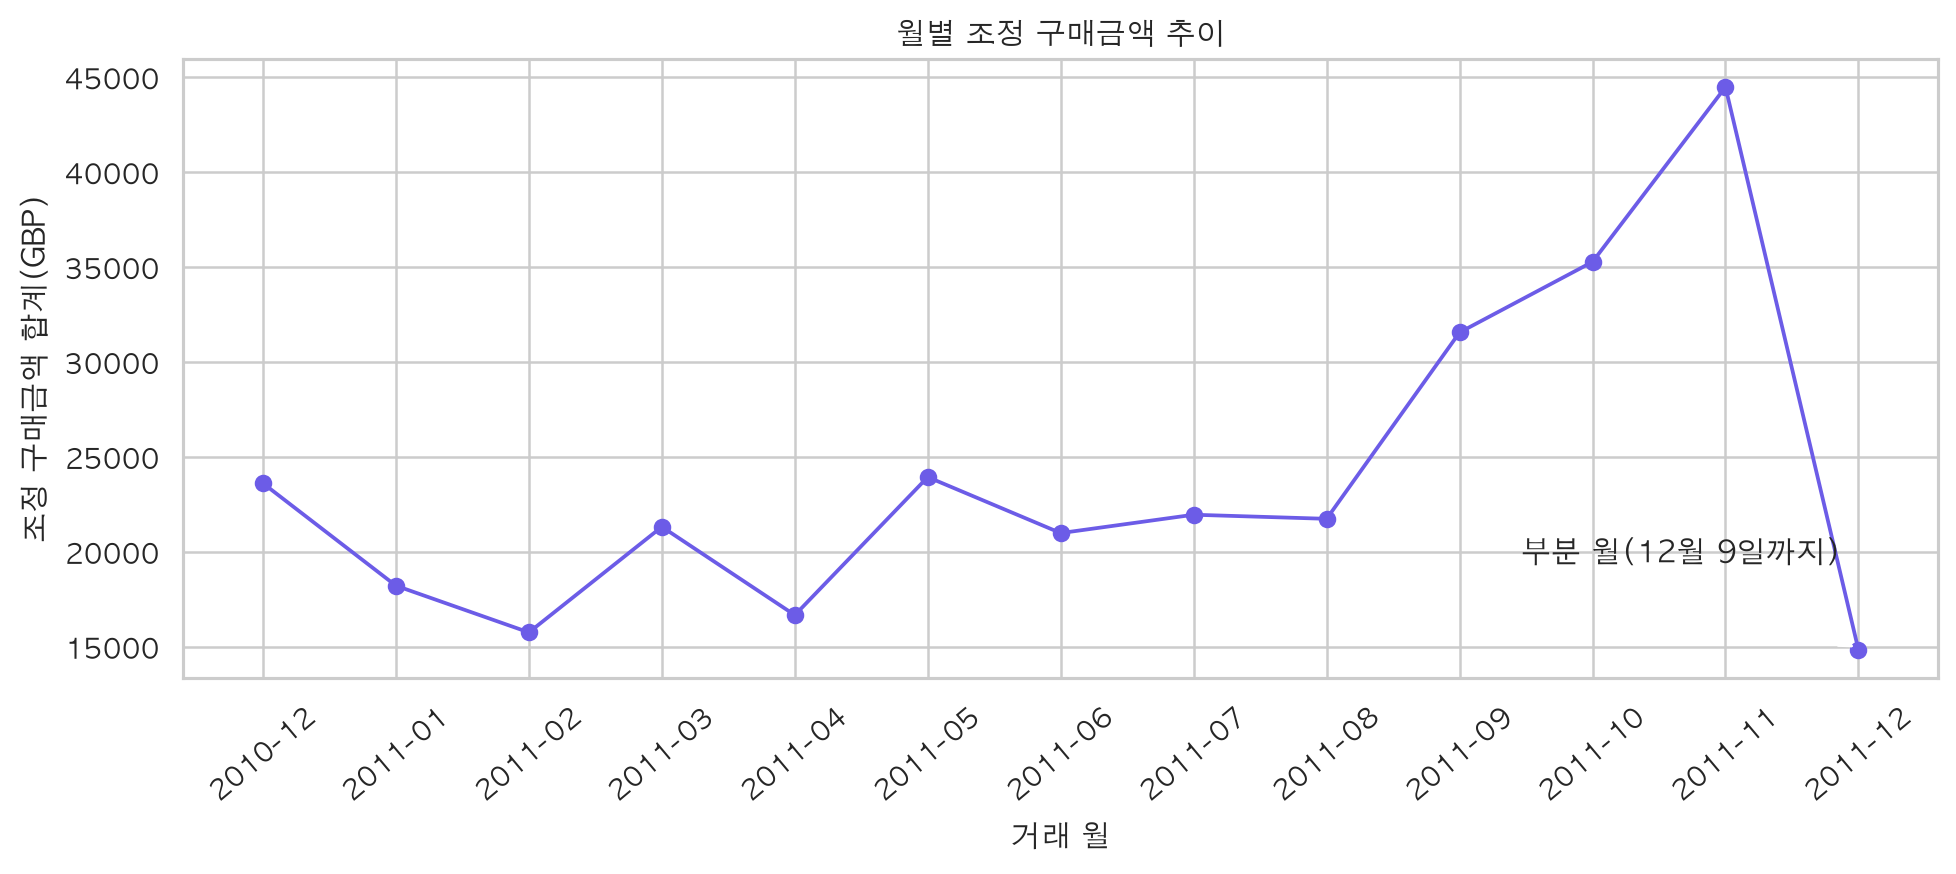

월별 그림의 마지막 12월은 부분 월이므로 전월과 직접 비교하지 않습니다.


In [8]:
# 현재 커널의 고객별 지표로 상관계수를 직접 다시 계산한다.
correlations = rfm[["Recency", "Frequency", "Monetary", "RFM_score"]].corr()
display(correlations)
display(Markdown(notes["correlations"]))
display(pd.DataFrame(FIGURE_METADATA).rename(columns={"file": "파일", "chart_type": "종류", "title": "제목", "x_axis": "가로축", "y_axis": "세로축"}))
for meta in FIGURE_METADATA:
    display(Image(filename=str(ROOT / "figures" / meta["file"])))
print("월별 그림의 마지막 12월은 부분 월이므로 전월과 직접 비교하지 않습니다.")

## 9. 점수 기준과 금액 처리의 민감도

In [9]:
display(Markdown(notes["sensitivity"]))
display(result["sensitivity"].round(3))

점수 구간 3·4·5개, 최근성 30·90·180일, 원본·조정 금액 시나리오를 비교한다. 홀수 구간은 중앙 점수를 상위 쪽에 포함하므로 단순히 구간 수만 바뀌는 비교는 아니다. 후보 기준은 정답이 아닌 가정이며 고객 수·금액 비중·기본 분류 대비 이동률로 운영 안정성을 확인한다. 조정 금액은 고객 순위와 매출 집중도를 바꿀 수 있어 두 기준을 함께 본다.

,시나리오,점수 구간 수,최근성 기준(일),금액 열,고객군,고객 수,고객 비중,금액 비중,기본 대비 분류 이동률
0,기본 4구간·조정 금액,4,NaN,amount_clean,장기 미구매 고객,1630,0.501,0.289,0.000
1,기본 4구간·조정 금액,4,NaN,amount_clean,반복 구매 고객,213,0.066,0.021,0.000
2,기본 4구간·조정 금액,4,NaN,amount_clean,최근 저빈도 고객,461,0.142,0.042,0.000
3,기본 4구간·조정 금액,4,NaN,amount_clean,핵심 우수 고객,947,0.291,0.648,0.000
4,3구간·조정 금액,3,NaN,amount_clean,장기 미구매 고객,1086,0.334,0.154,0.203
5,3구간·조정 금액,3,NaN,amount_clean,반복 구매 고객,117,0.036,0.008,0.203
6,3구간·조정 금액,3,NaN,amount_clean,최근 저빈도 고객,714,0.220,0.071,0.203
7,3구간·조정 금액,3,NaN,amount_clean,핵심 우수 고객,1334,0.410,0.767,0.203
8,5구간·조정 금액,5,NaN,amount_clean,장기 미구매 고객,1303,0.401,0.208,0.119
9,5구간·조정 금액,5,NaN,amount_clean,반복 구매 고객,178,0.055,0.015,0.119


## 10. 비즈니스 제안

In [10]:
for insight in result["insights"].values():
    display(Markdown(f"### {insight['title']}\n\n**근거**: {insight['evidence']}\n\n**실행과 기대 효과**: {insight['action']} {insight['expected_effect']}\n\n**검증**: {insight['validation_data']}"))

### 핵심 우수 고객 유지

**근거**: 핵심 우수 고객은 947명(29.1%)이며 조정 금액의 64.8%를 만든다. 평균 주문 수는 5.79회다.

**실행과 기대 효과**: 핵심 우수 고객에게 등급별 선공개·서비스 혜택을 제공한다. 첫 2주에 혜택 비용·마진 기준을 정하고 4주 캠페인 후 90일 반복구매율을 대조군과 비교한다. 기대 효과는 반복 구매와 주요 매출 기반의 유지다. 금액 기여도가 커 우선 검토하되 고객별 마진과 혜택 비용에 따라 우선순위를 조정한다.

**검증**: 대조군의 반복구매율·90일 미구매율, 고객별 마진과 혜택 비용이 필요하다. 반복구매율이 개선되지 않거나 증분 공헌이익이 0 이하라면 제안의 효과는 지지되지 않는다.

### 장기 미구매 고객 재방문

**근거**: 장기 미구매 고객은 1,630명(50.1%)이며 평균 최근성은 180.1일이다. 상대 점수 기준의 미구매 집단으로 확정 이탈자는 아니다.

**실행과 기대 효과**: 장기 미구매 고객을 대상으로 2주 준비 후 4주간 기간 제한 인센티브를 무작위 대조 실험한다. 증분 매출·공헌이익·수신거부율을 추적한다. 기대 효과는 전체 고객 할인 없이 일부 고객의 재방문을 유도하는 것이다. 할인비와 자연 재구매를 캠페인 효과로 오인할 위험을 함께 관리한다.

**검증**: 무작위 대조군의 자연 재구매, 이탈 사유, 할인 비용과 마진 데이터가 필요하다. 재방문율이나 증분 공헌이익이 대조군보다 개선되지 않으면 가설을 지지하지 않는다.

### 최근 저빈도 고객의 추가 구매

**근거**: 최근 저빈도 고객은 461명(14.2%)이고 표본 내 주문 빈도 중앙값은 1회다. 신규 가입이나 생애 첫 구매가 확인된 집단은 아니다.

**실행과 기대 효과**: 최근 저빈도 고객에게 마지막 관측 구매 후 상품 사용 안내와 연관상품을 제안하고 14/30일 추가 구매율을 대조군과 비교한다. 첫 구매 온보딩은 전체 구매 이력에서 첫 구매가 확인된 대상에만 적용한다. 기대 효과는 최근 구매 고객의 재방문과 추가 구매 전환이다. 추천의 관련성과 반품 증가를 함께 살핀다.

**검증**: 전체 구매 이력·추천 노출·클릭·반품 데이터가 필요하다. 추가 구매율이 대조군보다 높지 않거나 반품·혜택 비용이 성과를 상쇄하면 효과는 지지되지 않는다.

## 11. 대규모 처리와 머신러닝 확장

In [11]:
display(result["scaling"].round(3))
display(Markdown(notes["scaling"]))
display(Markdown(notes["ml"]))
display(Markdown(notes["limitations"]))

,배열 형식,이미지 수,용량(TB),용량(TiB)
0,흑백 uint8,1000000,1.049,0.954
1,RGB uint8,1000000,3.146,2.861
2,RGB float32,1000000,12.583,11.444


고객당 1024×1024 비압축 이미지 한 장을 가정하면 흑백 uint8는 약 1.05 TB,
RGB uint8는 약 3.15 TB, RGB float32는 약 12.58 TB다. 압축 파일 용량과 다르며
CSV 문자열·파싱 객체·임시 복사본은 추가 메모리를 쓴다. 실제 이미지 수는 고객 수가 아니라 고유 상품 수와 연결해 계산해야 한다.

전체 `np.stack()`의 RAM 요구량은 분명한 실행 불가 지점이다. 디스크·네트워크 읽기 또는 디코딩이
먼저 병목이 되는지는 프로파일링으로 확인한다. 고유 상품 이미지의 평균·표준편차를 한 번만 계산해 캐시하고,
이미지 또는 작은 배치마다 처리한 뒤 원본 배열을 해제한다. 배열 대신 작은 피처 표를 거래에 연결한다.
원본 uint8를 유지하고 필요시 `arr[::n, ::n]`으로 다운샘플링하며, CSV 픽셀 문자열 대신 NumPy 바이너리 등으로 저장한다.
필요시 메모리 매핑을 사용하고 CPU 병목이 확인된 뒤에만 병렬화한다. 프로세스마다 전체 데이터를 복사하면 RAM 문제가 커진다.

후속 예측 타깃은 과거 기준일 이후 90일간 구매가 없으면 `churn_90d=1`, 구매가 있으면 0으로 정의할 수 있다.
2011-12-10 이후의 거래는 현재 데이터에 없으므로 이 시점의 미래 레이블은 만들 수 없다.
마지막 관측일까지 이후 90일이 완전히 포함되는 과거 기준일을 선택하고, 그 이전에 활동한 고객을 대상으로 한다.
관측 기간 부족을 미구매로 오인하는 우측 검열을 관리하고, 거래 표본에서 빠진 구매도 이탈 오분류를 만들 수 있어 전체 이력이 필요하다.

현재 사용 가능한 피처는 최근성·구매 빈도·원본/조정 구매금액과 상품 설명의 단어 수 등이다.
거래 수준 피처를 고객 수준으로 집계하는 규칙을 정하고, 반품률·고유 상품 수·활동 개월 수·최근 30/60/90일 활동은 추가로 구현할 후보로 구분한다.
교육용 이미지 배열 통계는 시각적 의미나 예측력을 가정하지 않는다. 미래 주문·금액과 미래 캠페인 결과를 입력에서 제외한다.
기준일에 이미 알려진 RFM 세그먼트 자체는 미래 정보가 아니지만, 원 지표로부터 결정된 중복 피처이고 기준 변경에 민감해 기본 입력에서는 제외한다.
시간순 학습·검증·테스트 분할을 사용하고 정확도 외 PR-AUC·재현율·정밀도·확률 보정과 캠페인 비용을 반영한 기대가치를 확인한다.
확장 설계이며 현재 저장소에서 머신러닝 모델을 학습한 결과는 아니다.

거래 행 표본은 일부 주문 품목과 과거 구매를 빠뜨려 빈도·금액을 낮게 측정하거나 최근성을 늘릴 수 있다. 고객 단위로 표본을 뽑고 관측 기간 내 전체 거래를 유지하는 방식이 고객 행동 분석에 더 적합하다. 익명 거래는 고객 단위 결과에서 제외된다. 반품·취소는 구매 집계와 분리했으며 순매출·반품 행동은 별도 분석이 필요하다. 2011년 12월은 9일까지인 부분 월로 전월과 직접 비교하지 않는다. 교육용 배열을 실제 상품 이미지로 해석할 수 없다.

### 배열 연산의 선택 이유

금액은 `quantity.to_numpy() * unit_price.to_numpy()`로 계산한다.
배열 특징은 `np.stack()`으로 동종 자료형의 2차원 행렬을 만든 뒤 `mean(axis=1)`과 `std(axis=1)`로
이미지별 값을 한 번에 구한다. 단어 수는 Pandas 문자열 연산으로 만든다.
CSV 문자열을 배열로 복원하는 입출력 단계에는 행별 처리가 남아 있지만, 평균·표준편차 계산에 Python 행별 for문은 사용하지 않는다.

동종 자료형의 연속 메모리는 포인터 추적을 줄이고 CPU 캐시의 지역성을 높인다.
NumPy의 컴파일된 내부 루프는 Python 원소별 호출과 동적 타입 검사 비용을 줄이며,
지원되는 연산·자료형·CPU에서는 SIMD로 여러 값을 함께 처리할 수 있다.
모든 연산이 SIMD를 사용하거나 작은 배열에서도 항상 빠른 것은 아니다. 전체 행렬을 쌓는 메모리 비용도 고려해야 한다.
현재 0~255 배열은 float32로 충분하며 float64보다 핵심 행렬 메모리가 절반이다.

### 이미지 배열의 적용 범위

`product_image`는 `stock_code`를 해시해 만든 8×8 교육용 배열이다.
실제 상품 사진이나 UCI가 제공한 이미지가 아니며 색상·형태·품질을 뜻하지 않는다.
숫자·범주·날짜는 원본 거래에서 확보하고 배열은 파싱·벡터 통계의 동작을 살펴보는 데 사용한다.
실제 상품 이미지 분석으로 확장하려면 공개 라이선스 이미지와 정확한 상품 대응 관계가 필요하다.
관련 없는 사진을 임의로 상품에 연결해서는 안 된다. 빈 배열·길이가 다른 배열·비유한 값은 오류로 드러낸다.

### 대규모 처리의 가정

고객당 1024×1024 비압축 이미지 한 장을 가정하면 흑백 uint8는 약 1.05 TB,
RGB uint8는 약 3.15 TB, RGB float32는 약 12.58 TB다. 압축 파일 용량과 다르며
CSV 문자열·파싱 객체·임시 복사본은 추가 메모리를 쓴다. 실제 이미지 수는 고객 수가 아니라 고유 상품 수와 연결해 계산해야 한다.

전체 `np.stack()`의 RAM 요구량은 분명한 실행 불가 지점이다. 디스크·네트워크 읽기 또는 디코딩이
먼저 병목이 되는지는 프로파일링으로 확인한다. 고유 상품 이미지의 평균·표준편차를 한 번만 계산해 캐시하고,
이미지 또는 작은 배치마다 처리한 뒤 원본 배열을 해제한다. 배열 대신 작은 피처 표를 거래에 연결한다.
원본 uint8를 유지하고 필요시 `arr[::n, ::n]`으로 다운샘플링하며, CSV 픽셀 문자열 대신 NumPy 바이너리 등으로 저장한다.
필요시 메모리 매핑을 사용하고 CPU 병목이 확인된 뒤에만 병렬화한다. 프로세스마다 전체 데이터를 복사하면 RAM 문제가 커진다.

### 미래 타깃의 관측 조건

후속 예측 타깃은 과거 기준일 이후 90일간 구매가 없으면 `churn_90d=1`, 구매가 있으면 0으로 정의할 수 있다.
2011-12-10 이후의 거래는 현재 데이터에 없으므로 이 시점의 미래 레이블은 만들 수 없다.
마지막 관측일까지 이후 90일이 완전히 포함되는 과거 기준일을 선택하고, 그 이전에 활동한 고객을 대상으로 한다.
관측 기간 부족을 미구매로 오인하는 우측 검열을 관리하고, 거래 표본에서 빠진 구매도 이탈 오분류를 만들 수 있어 전체 이력이 필요하다.

현재 사용 가능한 피처는 최근성·구매 빈도·원본/조정 구매금액과 상품 설명의 단어 수 등이다.
거래 수준 피처를 고객 수준으로 집계하는 규칙을 정하고, 반품률·고유 상품 수·활동 개월 수·최근 30/60/90일 활동은 추가로 구현할 후보로 구분한다.
교육용 이미지 배열 통계는 시각적 의미나 예측력을 가정하지 않는다. 미래 주문·금액과 미래 캠페인 결과를 입력에서 제외한다.
기준일에 이미 알려진 RFM 세그먼트 자체는 미래 정보가 아니지만, 원 지표로부터 결정된 중복 피처이고 기준 변경에 민감해 기본 입력에서는 제외한다.
시간순 학습·검증·테스트 분할을 사용하고 정확도 외 PR-AUC·재현율·정밀도·확률 보정과 캠페인 비용을 반영한 기대가치를 확인한다.
확장 설계이며 현재 저장소에서 머신러닝 모델을 학습한 결과는 아니다.

### 결측 정책과 점수 선택

상품명은 그룹 최빈값, 수치형은 그룹 평균·중앙값으로 다룬다. 평균은 극단값에 민감하고 대치는 그룹 내부 분산을 줄일 수 있다. 고객 식별자는 대치하지 않는다. RFM은 사전 구매주기 기준이 없는 탐색에서 평균 순위 백분위 네 구간을 기본으로 사용하며, 동점을 보존하고 실제 운영 임계값과 민감도를 비교한다.